# Phishing Website Detection using Random Forest (Modular Version)
**Dataset:** PhiUSIIL Phishing URL Dataset (UCI, 2024)

Following the Week 4 requirement, this notebook is an **orchestration report only**:
it imports functions from separate modules (`config.py`, `data_pipeline.py`,
`model.py`, `train.py`, `evaluate.py`, `feature_extraction.py`) and calls them
in order. All the actual logic lives in those module files, not here.


## Step 0: Import our modules

In [1]:
import sys
sys.path.append("modules")   # folder containing our .py module files

import config
import data_pipeline
import model as model_module
import train as train_module
import evaluate as evaluate_module
import feature_extraction


## Step 1-2: Download (once) and load the dataset from local CSV

In [2]:
data_pipeline.download_and_save_dataset()
df = data_pipeline.load_dataset()
print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")


phiusiil_dataset.csv already exists — skipping download.
Loaded dataset: 235795 rows, 55 columns


## Step 3: Explore — total rows and class balance

In [3]:
class_counts = df["label"].value_counts()
print(f"Total rows: {len(df)}")
print(class_counts)


Total rows: 235795
label
1    134850
0    100945
Name: count, dtype: int64


## Step 4: Preprocess the data

In [4]:
df_numeric, url_text, X, y = data_pipeline.preprocess(df)
print(f"Features shape: {X.shape}, Label shape: {y.shape}")


Dropping non-numeric columns: ['URL', 'Domain', 'TLD', 'Title']
Total missing values: 0
Features shape: (235795, 50), Label shape: (235795,)


## Step 5: Stratified split (per class) then merge, and check for leakage

In [5]:
X_train, X_val, y_train, y_val, train_idx, val_idx = data_pipeline.stratified_split(df_numeric, X, y)
data_pipeline.check_no_leakage(train_idx, val_idx)


Train set: 188636 rows, Validation set: 47159 rows
Overlapping rows between train and validation: 0
No data leakage detected.


True

## Step 6: Build and train the Random Forest model

In [6]:
rf_model = model_module.build_model()
rf_model = train_module.train_model(rf_model, X_train, y_train)


Training on 188636 rows...
Training complete.


## Step 7: Evaluate — accuracy, classification report, confusion matrix

Validation Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



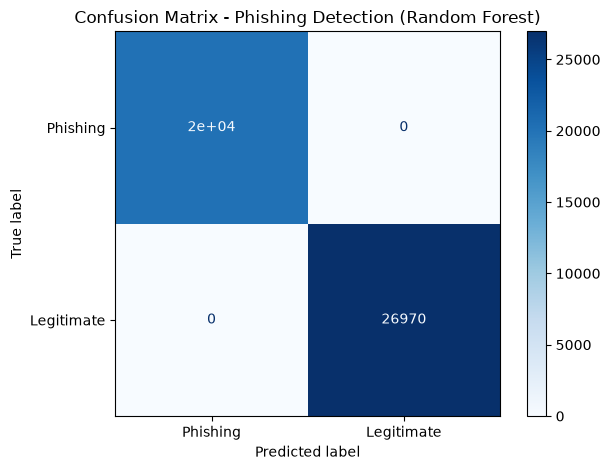

TP: 26970   TN: 20189   FP: 0   FN: 0
Accuracy: 1.0000  Precision: 1.0000  Recall: 1.0000  Specificity: 1.0000  F1: 1.0000


In [7]:
y_pred, accuracy = evaluate_module.evaluate_model(rf_model, X_val, y_val)
metrics = evaluate_module.plot_confusion_matrix(y_val, y_pred)


## Step 8: Feature importance

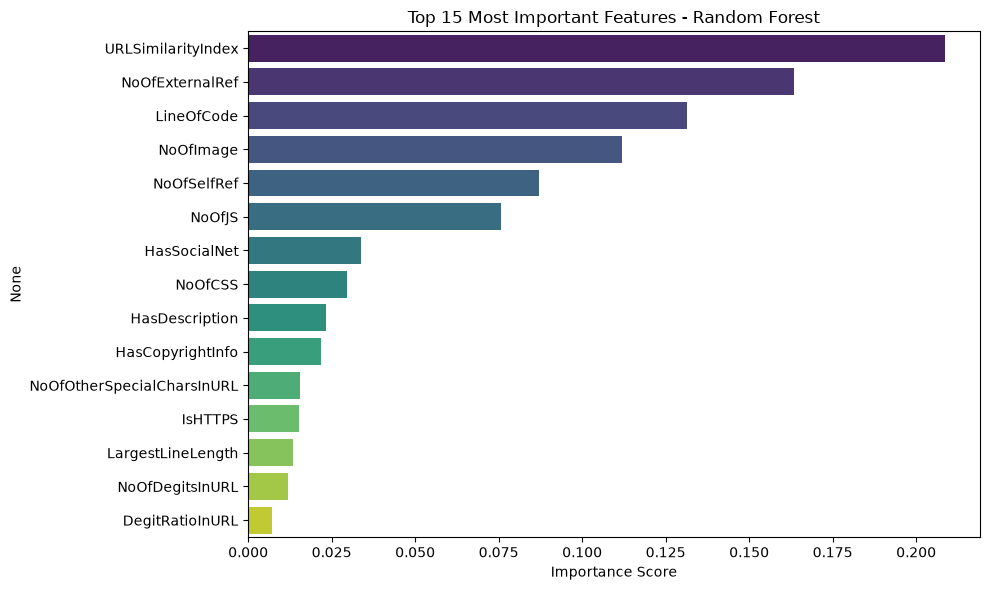

URLSimilarityIndex            0.208673
NoOfExternalRef               0.163370
LineOfCode                    0.131519
NoOfImage                     0.111867
NoOfSelfRef                   0.087212
NoOfJS                        0.075634
HasSocialNet                  0.033668
NoOfCSS                       0.029520
HasDescription                0.023418
HasCopyrightInfo              0.021906
NoOfOtherSpecialCharsInURL    0.015555
IsHTTPS                       0.015152
LargestLineLength             0.013408
NoOfDegitsInURL               0.011776
DegitRatioInURL               0.007251
dtype: float64


In [8]:
top_features = evaluate_module.plot_feature_importance(rf_model, X)
print(top_features)


## Step 9: Export prediction tables (validation + training) to Excel

In [9]:
val_results = evaluate_module.export_prediction_table(
    rf_model, X_val, y_val, url_text, config.VALIDATION_PREDICTIONS_PATH
)

train_results = evaluate_module.export_prediction_table(
    rf_model, X_train, y_train, url_text, config.TRAINING_PREDICTIONS_PATH
)


Saved prediction_results.xlsx (47159 rows)
Accuracy check: 1.0000
Saved training_prediction_results.xlsx (188636 rows)
Accuracy check: 1.0000


## Step 10: Predict on a BRAND NEW URL (answers sir's original question)

This is the part that answers: *"the dataset has 54 columns, but a real
user only gives 1 URL — what does the user need to input?"*

We take a raw URL (just text), automatically calculate the URL-based
features using `feature_extraction.py`, and feed that into the trained
model to get a live prediction — no dataset row required.


In [10]:
new_url = "http://fake-bank-login.xyz/verify?account=12345"  # try changing this!

feature_vector = feature_extraction.build_feature_vector(new_url, list(X.columns))
import pandas as pd
feature_df = pd.DataFrame([feature_vector])[X.columns]  # match column order

prediction = rf_model.predict(feature_df)[0]
probability = rf_model.predict_proba(feature_df)[0].max()

label = "Legitimate" if prediction == 1 else "Phishing"
print(f"URL: {new_url}")
print(f"Prediction: {label}  (confidence: {probability:.4f})")


Note: 33 columns require webpage source-code scraping (not just the URL) and were defaulted to 0: ['IsDomainIP', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'ObfuscationRatio']...
URL: http://fake-bank-login.xyz/verify?account=12345
Prediction: Phishing  (confidence: 0.9950)


In [11]:
# Test with a LEGITIMATE URL for comparison
legit_url = "https://www.google.com"

legit_feature_vector = feature_extraction.build_feature_vector(legit_url, list(X.columns))
legit_feature_df = pd.DataFrame([legit_feature_vector])[X.columns]

legit_prediction = rf_model.predict(legit_feature_df)[0]
legit_probability = rf_model.predict_proba(legit_feature_df)[0].max()

legit_label = "Legitimate" if legit_prediction == 1 else "Phishing"
print(f"URL: {legit_url}")
print(f"Prediction: {legit_label}  (confidence: {legit_probability:.4f})")

Note: 33 columns require webpage source-code scraping (not just the URL) and were defaulted to 0: ['IsDomainIP', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'ObfuscationRatio']...
URL: https://www.google.com
Prediction: Phishing  (confidence: 0.9700)


## Summary

- Code is split into modules: `config.py`, `data_pipeline.py`, `model.py`,
  `train.py`, `evaluate.py`, `feature_extraction.py`
- This notebook only orchestrates — calls functions, no heavy logic here
- Full dataset used, stratified split verified with no data leakage
- Model trained, evaluated, and prediction tables exported to Excel
- New: a live URL can now be fed into the model via `feature_extraction.py`,
  closing the gap between the 54 training columns and a real user's single URL input
